In [1]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 4.6 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import math
#from ultralytics import YOLO

In [3]:
device = torch.device("cuda")

In [25]:
np.random.seed(3)

def show_mask(mask, ax, random_color=True, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=50):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

In [4]:
plt.rcParams['figure.figsize'] = [10, 10]

In [5]:
def yolo_boxes(image, model):
    h, w = image.shape[:2]
    get_factor = lambda size: 4 if size >= 10000 else (2 if size >= 5000 else 1)
    split_h, split_w = get_factor(h), get_factor(w)

    if split_h == 1 and split_w == 1:
        boxes,_ = model(image)
        return boxes

    step_h, step_w = h // split_h, w // split_w
    global_yolo_boxes = []

    for i in range(split_h):
        for j in range(split_w):
            y1, x1 = i * step_h, j * step_w
            y2 = h if i == split_h - 1 else (i + 1) * step_h
            x2 = w if j == split_w - 1 else (j + 1) * step_w

            crop_img = image[y1:y2, x1:x2]
            boxes,_ = model(crop_img)

            if len(boxes) > 0:
                boxes[:, [0, 2]] += x1
                boxes[:, [1, 3]] += y1
                global_yolo_boxes.append(boxes)

    if len(global_yolo_boxes) > 0:
        return np.vstack(global_yolo_boxes)
    return np.empty((0, 4))

In [6]:
def find_crop(image, boxes):
    crops, positions = [], []
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        crops.append(image[y1:y2, x1:x2].copy())
        positions.append((y1, y2, x1, x2))
    return crops, positions

In [7]:
def mask_full(mask,h,w,position) :
    mask_f = np.zeros((h, w), dtype=np.uint8)
    y1, y2, x1, x2 = position
    mask_f[y1:y2, x1:x2] = mask
    return mask_f

In [8]:
def clean_mask(masks, sam_scores, yolo_scores, thresh=0.5):
    sam_scores = np.array(sam_scores).flatten()
    yolo_scores = np.array(yolo_scores).flatten()
    combined_scores = sam_scores * yolo_scores

    sorted_indices = np.argsort(combined_scores)[::-1]

    h, w = masks[0].shape[:2]
    occupied_region = np.zeros((h, w), dtype=bool)

    final_masks = []
    final_scores = []

    for idx in sorted_indices:
        current_mask = masks[idx].astype(bool)
        current_area = np.count_nonzero(current_mask)

        cleaned_mask = current_mask & (~occupied_region)
        cleaned_area = np.count_nonzero(cleaned_mask)

        if current_area > 0 and (cleaned_area / current_area) > thresh:
            final_masks.append(cleaned_mask.astype(np.uint8))
            final_scores.append(combined_scores[idx])

            occupied_region = occupied_region | cleaned_mask

    return final_masks, final_scores

In [13]:
iname = "/content/drive/MyDrive/Yolo/Data_crop/images/train/1.X5.1.883.jpg"

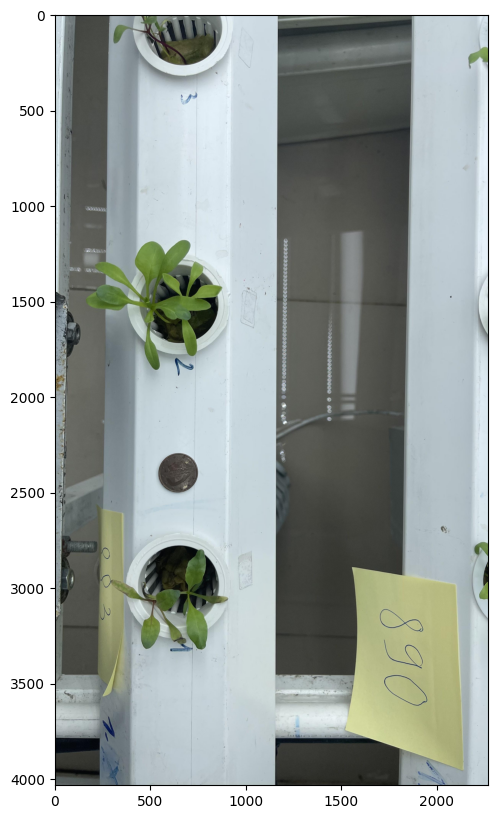

In [14]:
image = cv2.imread(iname)
image.shape
plt.imshow(image[:,:,::-1])
plt.show()

In [17]:
image_pil = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

In [15]:
import sys
sys.path.append('/content/drive/MyDrive/onnx')

In [16]:
from yolo_onnx import YOLO_ONNX

In [18]:
model1 = YOLO_ONNX("/content/drive/MyDrive/onnx/model/yolo1.onnx")

In [19]:
%%time
final_boxes = yolo_boxes(image_pil, model1)
crops, positions = find_crop(np.array(image_pil), final_boxes)

CPU times: user 2.12 s, sys: 199 ms, total: 2.31 s
Wall time: 2.94 s


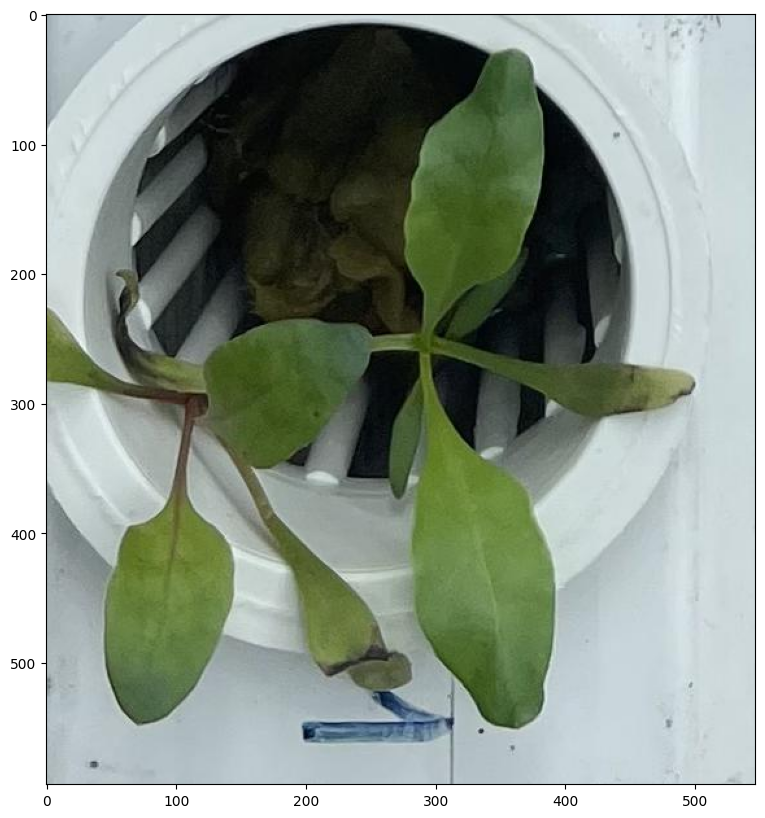

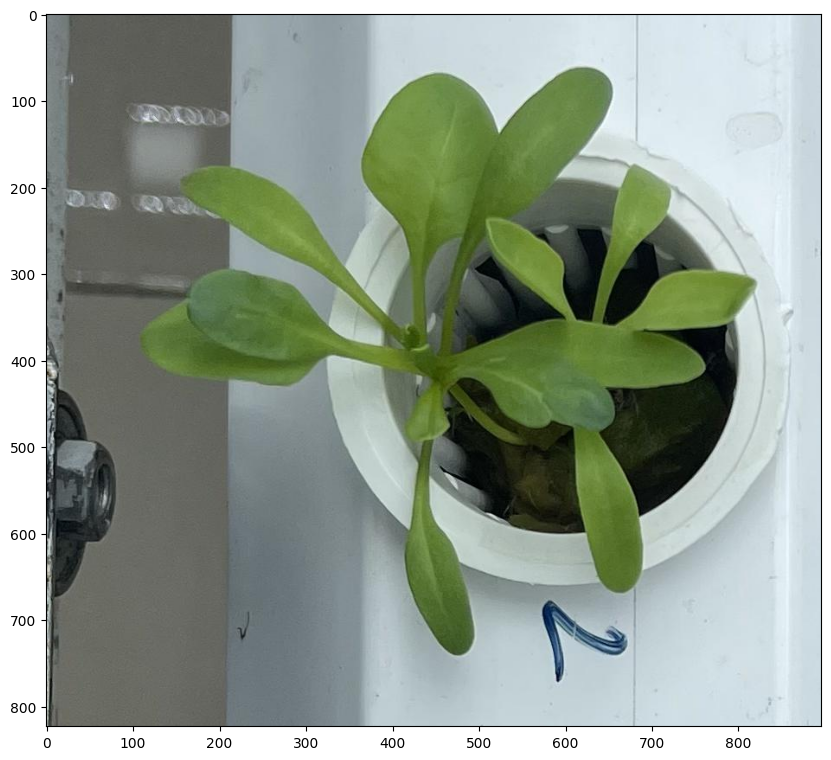

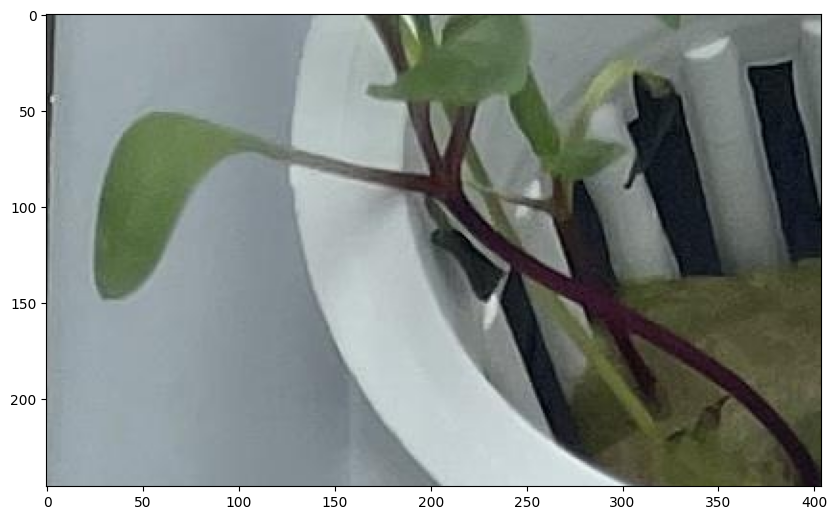

In [20]:
for img in crops:
    plt.imshow(img)
    plt.show()

In [21]:
from sam2_onnx import SegmentAnything2ONNX

encoder_path = "/content/drive/MyDrive/onnx/model/sam2.1_hiera_tiny.encoder.onnx"
decoder_path = "/content/drive/MyDrive/onnx/model/sam2.1_hiera_tiny.decoder.onnx"

# Khởi tạo
sam2_onnx = SegmentAnything2ONNX(encoder_path, decoder_path)

In [22]:
model2 = YOLO_ONNX("/content/drive/MyDrive/onnx/model/yolo2.onnx")

In [23]:
h,w = image.shape[:2]

In [28]:
%%time
masks_all = []
for i in range(len(crops)):
    embeddings = sam2_onnx.encode(crops[i])
    boxes,scores_yolo = model2(crops[i],conf =0.5, iou =0.7)

    masks = []
    scores_sam = []
    for box in boxes:
        prompt = [{"type": "rectangle", "data": box.tolist()}]
        mask_result, score = sam2_onnx.predict_masks(embeddings, prompt)
        masks.append(mask_result[0, 0])
        scores_sam.append(score)

    final_masks, final_scores = clean_mask(masks, scores_sam, scores_yolo)

    for m in final_masks :
        mask_cf = mask_full(m,h,w,positions[i])
        masks_all.append(mask_cf)
"""
    plt.figure(figsize=(10, 10))
    plt.imshow(crops[i])

    for mask in final_masks:
        show_mask(mask > 0, plt.gca(), random_color=True)

    for box in boxes:
        show_box(box, plt.gca())

    plt.axis('off')
    plt.show()"""

Encoder infer time: 193.04 ms
Decoder infer time: 7.64 ms
Decoder infer time: 8.34 ms
Decoder infer time: 7.26 ms
Decoder infer time: 7.19 ms
Decoder infer time: 7.19 ms
Decoder infer time: 7.16 ms
Decoder infer time: 5.85 ms
Decoder infer time: 4.71 ms
Decoder infer time: 4.64 ms
Encoder infer time: 130.64 ms
Decoder infer time: 5.90 ms
Decoder infer time: 5.48 ms
Decoder infer time: 5.38 ms
Decoder infer time: 5.34 ms
Decoder infer time: 5.50 ms
Decoder infer time: 5.31 ms
Decoder infer time: 5.27 ms
Decoder infer time: 5.27 ms
Decoder infer time: 5.32 ms
Decoder infer time: 5.35 ms
Decoder infer time: 5.28 ms
Decoder infer time: 5.28 ms
Decoder infer time: 5.30 ms
Encoder infer time: 133.40 ms
Decoder infer time: 7.75 ms
Decoder infer time: 10.81 ms
Decoder infer time: 7.39 ms
Decoder infer time: 5.37 ms
CPU times: user 785 ms, sys: 16.9 ms, total: 802 ms
Wall time: 850 ms


"\n    plt.figure(figsize=(10, 10))\n    plt.imshow(crops[i])\n\n    for mask in final_masks:\n        show_mask(mask > 0, plt.gca(), random_color=True)\n\n    for box in boxes:\n        show_box(box, plt.gca())\n\n    plt.axis('off')\n    plt.show()"

In [26]:
len(masks_all)

26

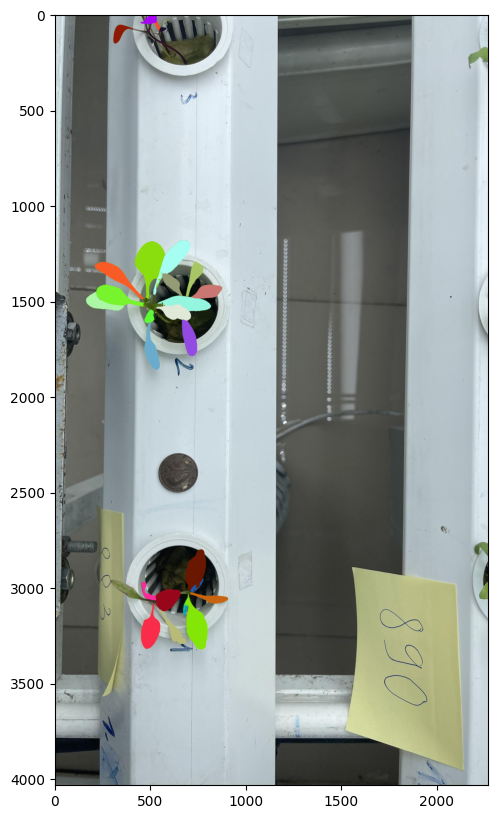

In [27]:
image_display = image_pil.copy()
for i in masks_all :
    color = np.random.randint(0, 256, size=(3,), dtype=np.uint8)
    image_display[i > 0] = color
plt.imshow(image_display)
plt.show()